# 27_distribution_shift_visual.ipynb

Распределенческий shift между train-fresh и test **есть**, но `c_max`,
`c_range`, `c_std` его не объясняют. Этот ноутбук пытается найти, что **на
самом деле** отличается.

## Что делаем

1. Грузим обученную модель и per-sample метрики из ноутбука 26 (vanilla FNO).
2. **Качественная часть:** для каждого из нескольких бинов `c_max` находим
   пары:
   - train-fresh с **низким** RMSE
   - test с **высоким** RMSE при том же `c_max`
   и показываем их рядом — target / pred / error map. Глазами видим,
   что отличается.
3. **Количественная часть:** для каждого сэмпла считаем расширенный набор
   признаков:
   - `phantom_area` — площадь фантома в пикселях
   - `phantom_centroid_dist_to_center` — насколько фантом смещён к границе
   - `n_inclusions` — число связных контрастных регионов
   - `mean_inclusion_size` — средний размер включения
   - `edge_sharpness` — мера резкости границ (норма градиента)
   - `inclusion_density` — фракция площади фантома, занятая включениями
4. **Стат-тест:** для каждого признака — Mann-Whitney U test между train-fresh
   и test. Какие признаки статистически отличаются? Это и есть «скрытая ось»
   distribution shift.

## 1. Импорты и пути

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from scipy import ndimage
from scipy.stats import mannwhitneyu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Where the trained model and metrics live (from notebook 26)
RUN_DIR = Path("/workspace/reference_points/distribution_shift_diagnostic")
CKPT = RUN_DIR / "distshift_fno_best.pt"
METRICS_PATH = RUN_DIR / "per_sample_metrics.json"
SPLIT_PATH = RUN_DIR / "split_manifest.json"

assert CKPT.exists(), f"Checkpoint not found at {CKPT}"
assert METRICS_PATH.exists(), f"Metrics not found at {METRICS_PATH}"
assert SPLIT_PATH.exists(), f"Split manifest not found at {SPLIT_PATH}"

with open(METRICS_PATH) as f:
    saved_metrics = json.load(f)
with open(SPLIT_PATH) as f:
    split = json.load(f)

m_train_fresh = saved_metrics["train_fresh"]
m_test = saved_metrics["test"]
print(f"loaded metrics: train-fresh={len(m_train_fresh)}, test={len(m_test)}")

device: cuda
loaded metrics: train-fresh=1000, test=800


## 2. Загрузка обученной модели и `M_hom`

In [3]:
# === SpectralConv2d / FNO blocks (same as notebook 26) ===
class SpectralConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, modes1, modes2):
        super().__init__()
        self.in_channels = in_ch
        self.out_channels = out_ch
        self.modes1 = modes1
        self.modes2 = modes2
        scale = 1 / (in_ch * out_ch)
        self.weights1 = nn.Parameter(scale * torch.randn(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        with torch.autocast(device_type=x.device.type, enabled=False):
            x = x.float()
            x_ft = torch.fft.rfft2(x)
            out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1) // 2 + 1,
                                 dtype=torch.cfloat, device=x.device)
            out_ft[:, :, : self.modes1, : self.modes2] = self.compl_mul2d(
                x_ft[:, :, : self.modes1, : self.modes2], self.weights1)
            out_ft[:, :, -self.modes1:, : self.modes2] = self.compl_mul2d(
                x_ft[:, :, -self.modes1:, : self.modes2], self.weights2)
            out = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return out


class FNOBlock2d(nn.Module):
    def __init__(self, width, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes1, modes2)
        self.pointwise = nn.Conv2d(width, width, kernel_size=1)
    def forward(self, x):
        return F.gelu(self.spectral(x) + self.pointwise(x))


class FNO2dBaseline(nn.Module):
    def __init__(self, width=48, depth=4, modes1=24, modes2=24, padding=8, target_hw=(192, 192)):
        super().__init__()
        self.width = width; self.depth = depth; self.padding = padding
        self.target_hw = tuple(target_hw)
        self.input_proj = nn.Conv2d(4, width, kernel_size=1)
        self.blocks = nn.ModuleList([FNOBlock2d(width, modes1, modes2) for _ in range(depth)])
        self.head = nn.Sequential(
            nn.Conv2d(width, width, 1), nn.GELU(),
            nn.Conv2d(width, 1, 1),
        )

    def get_grid(self, batch_size, device):
        H_, W_ = self.target_hw
        yy = torch.linspace(-1.0, 1.0, H_, device=device)
        xx = torch.linspace(-1.0, 1.0, W_, device=device)
        gy, gx = torch.meshgrid(yy, xx, indexing="ij")
        return torch.stack([gy, gx], dim=0).unsqueeze(0).repeat(batch_size, 1, 1, 1)

    def forward(self, x):
        x = F.interpolate(x, size=self.target_hw, mode="bilinear", align_corners=False)
        grid = self.get_grid(x.shape[0], x.device)
        x = torch.cat([x, grid], dim=1)
        x = self.input_proj(x)
        if self.padding > 0:
            x = F.pad(x, [0, self.padding, 0, self.padding])
        for block in self.blocks:
            x = block(x)
        if self.padding > 0:
            x = x[..., :self.target_hw[0], :self.target_hw[1]]
        return self.head(x)


# Load checkpoint
ckpt = torch.load(CKPT, map_location=device)
cfg = ckpt["config"]
stats = ckpt["stats"]

# Read H, W, S, R from a sample
sample0 = np.load(split["train_fresh"][0])
S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])
receiver_y_full = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x_full = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

model = FNO2dBaseline(
    width=cfg["fno_width"], depth=cfg["fno_depth"],
    modes1=cfg["fno_modes_h"], modes2=cfg["fno_modes_w"],
    padding=cfg["fno_padding"], target_hw=(H, W),
).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"FNO loaded, best_epoch={ckpt['best_epoch']}, stats={stats}")

FNO loaded, best_epoch=27, stats={'c_min': 1404.1473388671875, 'c_max': 1598.34423828125}


In [4]:
# Compute M_hom (same recipe as notebook 26)
import jax
import jax.numpy as jnp
from jax import jit
from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    return (g / g.sum()).astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0, x0 = int(receiver_y_full[ridx]), int(receiver_x_full[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    return Medium(domain=domain, sound_speed=sound_speed, density=1000.0, pml_size=16)

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y_full, receiver_x_full])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

c_hom = jnp.full((H, W), 1500.0, dtype=jnp.float32)
M_hom_complex = np.array(forward_measurements_full_jit(c_hom).block_until_ready())
print("M_hom computed:", M_hom_complex.shape)

/tmp/ipykernel_845/877785251.py:9: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


M_hom computed: (16, 256)


## 3. Sample loader + predictor

In [5]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    Sl, Rl = M.shape
    for s in range(Sl):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % Rl
            M[s, rr] = 0.0 + 0.0j
    return M

def load_sample(path):
    d = np.load(path)
    x_raw = d["x"].astype(np.float32)
    c = d["c"].astype(np.float32)
    src_ring = d["source_ring_idx"].astype(np.int64)

    M = x_raw[0] + 1j * x_raw[1]
    M = M - M_hom_complex
    M = mask_self_receivers(M, src_ring, half_width=2)

    x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)
    x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
    if x_scale < 1e-8: x_scale = 1.0
    x_tensor = x_tensor / x_scale
    return x_tensor, c

@torch.no_grad()
def predict(x_tensor):
    x = torch.from_numpy(x_tensor).unsqueeze(0).to(device)
    pred = model(x)[0, 0].cpu().numpy()
    pred = np.clip(pred, -1.0, 1.0)
    c_min, c_max = stats["c_min"], stats["c_max"]
    return ((pred + 1.0) * 0.5) * (c_max - c_min) + c_min

## 4. Расширенные характеристики target

Для каждого target-сэмпла считаем 8 признаков:

- `phantom_area` — площадь, где `|c-1500| > 10` м/с
- `phantom_centroid_y/x` — центр масс
- `centroid_offset` — расстояние центра масс до центра картинки (нормировано)
- `mean_radius` — средний радиус фантома (sqrt(area/π))
- `n_inclusions` — число связных компонент с `c < 1490` (тёмные включения)
- `mean_inclusion_size` — средний размер включения (пиксели)
- `inclusion_density` — фракция площади фантома, занятая включениями
- `edge_sharpness` — норма градиента target в пикселях границы фантома

In [6]:
def compute_features(c, background=1500.0, threshold=10.0):
    """Compute extended target characteristics."""
    H_, W_ = c.shape
    phantom_mask = np.abs(c - background) > threshold
    n_phantom = int(phantom_mask.sum())

    if n_phantom == 0:
        return {
            "phantom_area": 0, "centroid_y": H_/2, "centroid_x": W_/2,
            "centroid_offset": 0.0, "mean_radius": 0.0,
            "n_inclusions": 0, "mean_inclusion_size": 0.0,
            "inclusion_density": 0.0, "edge_sharpness": 0.0,
            "c_max": float(c.max()), "c_min": float(c.min()),
            "c_std": float(c.std()), "c_range": float(c.max() - c.min()),
        }

    # Centroid + offset to image center
    yy, xx = np.where(phantom_mask)
    cy, cx = float(yy.mean()), float(xx.mean())
    img_cy, img_cx = (H_ - 1) / 2, (W_ - 1) / 2
    offset = np.sqrt((cy - img_cy) ** 2 + (cx - img_cx) ** 2)
    offset_norm = offset / (H_ / 2)   # normalized: 0 = centered, 1 = edge

    # Mean radius
    mean_radius = float(np.sqrt(n_phantom / np.pi))

    # Inclusions: dark regions inside phantom (c < 1490 ⇒ 10 m/s below background)
    inclusion_mask = (c < (background - threshold)) & phantom_mask
    labeled, n_inclusions = ndimage.label(inclusion_mask)
    if n_inclusions > 0:
        sizes = ndimage.sum(inclusion_mask, labeled, range(1, n_inclusions + 1))
        mean_inclusion_size = float(sizes.mean())
    else:
        mean_inclusion_size = 0.0
    inclusion_density = float(inclusion_mask.sum() / max(n_phantom, 1))

    # Edge sharpness: mean |∇c| on phantom boundary
    grad_y, grad_x = np.gradient(c)
    grad_mag = np.sqrt(grad_y ** 2 + grad_x ** 2)
    boundary = phantom_mask & ~ndimage.binary_erosion(phantom_mask)
    if boundary.sum() > 0:
        edge_sharpness = float(grad_mag[boundary].mean())
    else:
        edge_sharpness = 0.0

    return {
        "phantom_area": n_phantom,
        "centroid_y": cy, "centroid_x": cx,
        "centroid_offset": float(offset_norm),
        "mean_radius": mean_radius,
        "n_inclusions": int(n_inclusions),
        "mean_inclusion_size": mean_inclusion_size,
        "inclusion_density": inclusion_density,
        "edge_sharpness": edge_sharpness,
        "c_max": float(c.max()), "c_min": float(c.min()),
        "c_std": float(c.std()), "c_range": float(c.max() - c.min()),
    }

# Smoke test
_x0, _c0 = load_sample(split["train_fresh"][0])
_f0 = compute_features(_c0)
for k, v in _f0.items():
    print(f"  {k:<28}: {v}")

  phantom_area                : 12803
  centroid_y                  : 97.90611575412012
  centroid_x                  : 95.25072248691713
  centroid_offset             : 0.025197854874428657
  mean_radius                 : 63.83824459374703
  n_inclusions                : 10
  mean_inclusion_size         : 1024.9
  inclusion_density           : 0.8005155041787081
  edge_sharpness              : 28.62441635131836
  c_max                       : 1550.1187744140625
  c_min                       : 1428.9237060546875
  c_std                       : 30.233102798461914
  c_range                     : 121.195068359375


## 5. Считаем признаки для всех train-fresh и test

Это занимает ~30 секунд (1800 файлов × ~15ms на простую обработку target'а).

In [7]:
import time

def features_for_set(metrics_list, label):
    rows = []
    t0 = time.time()
    for i, m in enumerate(metrics_list):
        c = np.load(m["path"])["c"].astype(np.float32)
        feat = compute_features(c)
        feat["split"] = label
        feat["path"] = m["path"]
        feat["rmse"] = m["rmse"]
        rows.append(feat)
        if (i + 1) % 200 == 0:
            print(f"  {label}: {i+1}/{len(metrics_list)}  [{time.time()-t0:.1f}s]")
    return rows

print("Computing features for train-fresh...")
features_fresh = features_for_set(m_train_fresh, "train-fresh")
print("Computing features for test...")
features_test = features_for_set(m_test, "test")
all_features = features_fresh + features_test

print(f"\nTotal: {len(all_features)} samples processed")

Computing features for train-fresh...
  train-fresh: 200/1000  [0.3s]
  train-fresh: 400/1000  [0.6s]
  train-fresh: 600/1000  [0.9s]
  train-fresh: 800/1000  [1.2s]
  train-fresh: 1000/1000  [1.5s]
Computing features for test...
  test: 200/800  [0.3s]
  test: 400/800  [0.6s]
  test: 600/800  [0.9s]
  test: 800/800  [1.2s]

Total: 1800 samples processed


## 6. Статистический тест — какие признаки отличаются между train-fresh и test?

Mann-Whitney U test по каждому признаку. Признаки с маленьким p-value показывают
**статистически значимое** различие распределений между train-fresh и test.

In [8]:
feature_names = [
    "phantom_area", "centroid_offset", "mean_radius",
    "n_inclusions", "mean_inclusion_size", "inclusion_density",
    "edge_sharpness", "c_max", "c_min", "c_std", "c_range",
]

print("\n=== Distribution comparison: train-fresh vs test ===\n")
print(f"  {'feature':<24}{'fresh_mean':>12}{'test_mean':>12}{'fresh_med':>12}{'test_med':>12}{'p-value':>14}{'flag':>7}")
print("  " + "-" * 95)

stat_results = {}
for name in feature_names:
    fresh_vals = np.array([f[name] for f in features_fresh])
    test_vals = np.array([f[name] for f in features_test])

    try:
        stat, pval = mannwhitneyu(fresh_vals, test_vals, alternative="two-sided")
    except ValueError:
        pval = 1.0

    flag = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""

    stat_results[name] = {
        "fresh_mean": float(fresh_vals.mean()),
        "test_mean": float(test_vals.mean()),
        "fresh_median": float(np.median(fresh_vals)),
        "test_median": float(np.median(test_vals)),
        "p_value": float(pval),
    }

    print(f"  {name:<24}{fresh_vals.mean():>12.3f}{test_vals.mean():>12.3f}"
          f"{np.median(fresh_vals):>12.3f}{np.median(test_vals):>12.3f}"
          f"{pval:>14.2e}{flag:>7}")

# Save summary
with open(RUN_DIR / "feature_distribution_comparison.json", "w") as f:
    json.dump(stat_results, f, ensure_ascii=False, indent=2)
print(f"\n*** = p<0.001, ** = p<0.01, * = p<0.05")


=== Distribution comparison: train-fresh vs test ===

  feature                   fresh_mean   test_mean   fresh_med    test_med       p-value   flag
  -----------------------------------------------------------------------------------------------
  phantom_area               10032.033   10012.264    9868.500    9928.500      8.97e-01       
  centroid_offset                0.027       0.028       0.027       0.027      3.27e-01       
  mean_radius                   56.264      56.208      56.047      56.217      8.97e-01       
  n_inclusions                  25.013      25.380      12.000      12.000      8.17e-01       
  mean_inclusion_size         1569.158    1480.757     700.176     712.181      9.02e-01       
  inclusion_density              0.721       0.721       0.793       0.791      7.23e-01       
  edge_sharpness                23.225      23.105      25.449      23.275      7.09e-01       
  c_max                       1556.789    1556.859    1554.398    1554.571     

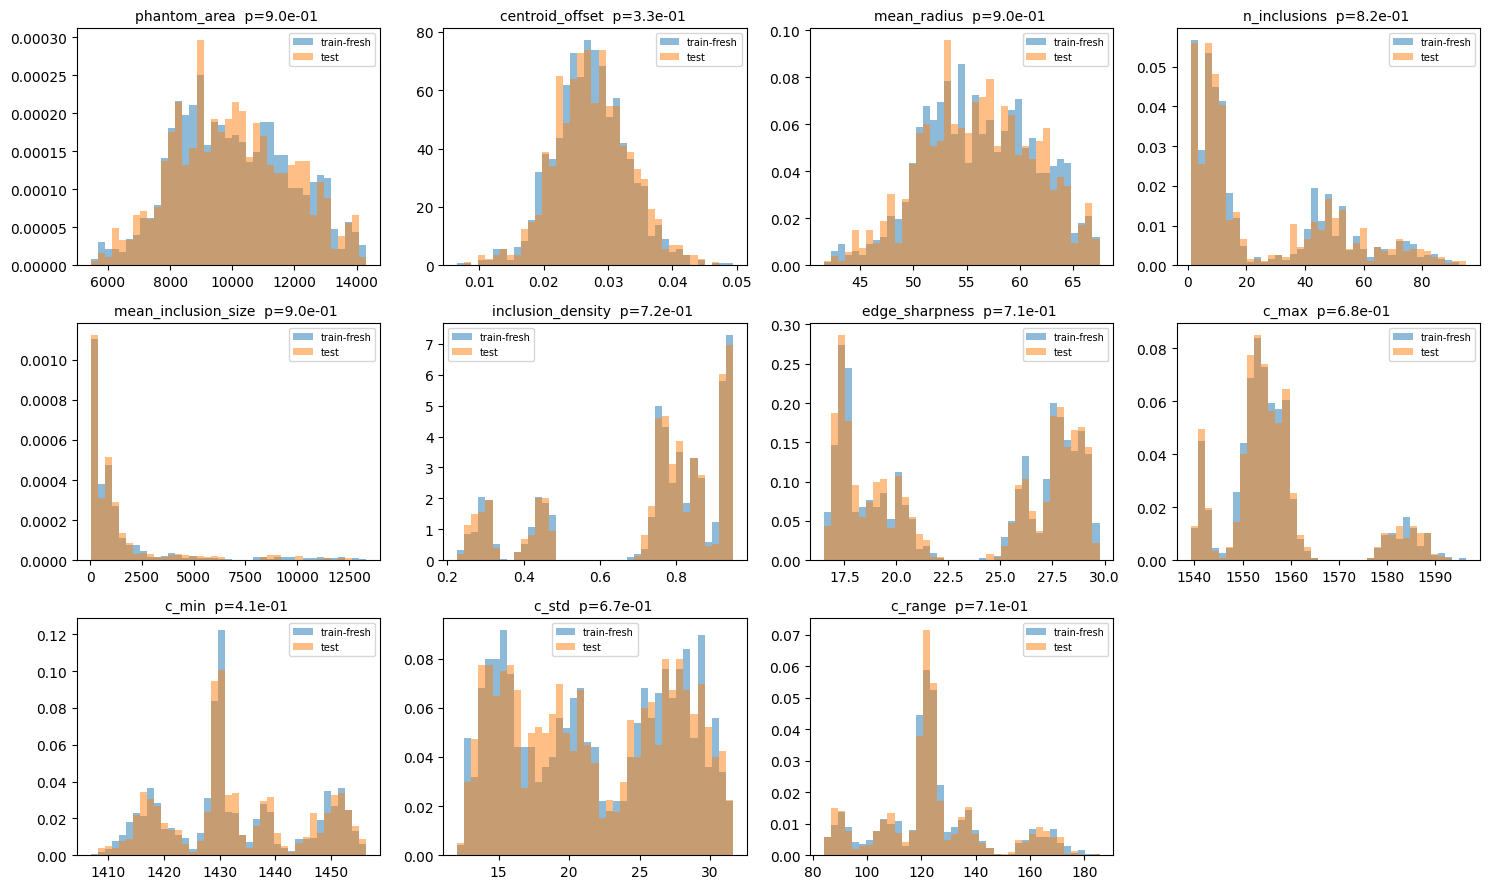

In [9]:
# Visualize distributions: histograms per feature, train-fresh vs test
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
axes = axes.flatten()

for ax, name in zip(axes, feature_names):
    fresh_vals = np.array([f[name] for f in features_fresh])
    test_vals = np.array([f[name] for f in features_test])
    bins = np.linspace(min(fresh_vals.min(), test_vals.min()),
                       max(fresh_vals.max(), test_vals.max()), 40)
    ax.hist(fresh_vals, bins=bins, alpha=0.5, label="train-fresh", density=True)
    ax.hist(test_vals, bins=bins, alpha=0.5, label="test", density=True)
    pval = stat_results[name]["p_value"]
    flag = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    ax.set_title(f"{name}  p={pval:.1e} {flag}", fontsize=10)
    ax.legend(fontsize=7)

# Hide last subplot if unused
for ax in axes[len(feature_names):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(RUN_DIR / "feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Корреляция каждого признака с RMSE внутри каждого split

Если test систематически имеет признак X выше, и при этом RMSE сильно зависит от
X, то X — кандидат на причину shift'а. Если корреляция X→RMSE есть в обоих
сплитах одинаковая, то наш фокус — выяснить **почему** распределение X в test
смещено.

In [10]:
print("\n=== Correlation feature → RMSE (Spearman) ===\n")
print(f"  {'feature':<24}{'fresh corr':>15}{'test corr':>15}")
print("  " + "-" * 60)

from scipy.stats import spearmanr
for name in feature_names:
    fresh_vals = np.array([f[name] for f in features_fresh])
    test_vals = np.array([f[name] for f in features_test])
    fresh_rmse = np.array([f["rmse"] for f in features_fresh])
    test_rmse = np.array([f["rmse"] for f in features_test])

    if fresh_vals.std() > 1e-6:
        c_fresh, _ = spearmanr(fresh_vals, fresh_rmse)
    else: c_fresh = 0.0
    if test_vals.std() > 1e-6:
        c_test, _ = spearmanr(test_vals, test_rmse)
    else: c_test = 0.0

    print(f"  {name:<24}{c_fresh:>15.3f}{c_test:>15.3f}")


=== Correlation feature → RMSE (Spearman) ===

  feature                      fresh corr      test corr
  ------------------------------------------------------------
  phantom_area                      0.138          0.147
  centroid_offset                   0.130          0.159
  mean_radius                       0.138          0.147
  n_inclusions                      0.483          0.556
  mean_inclusion_size              -0.461         -0.528
  inclusion_density                -0.579         -0.630
  edge_sharpness                    0.375          0.378
  c_max                             0.126          0.180
  c_min                            -0.745         -0.809
  c_std                             0.419          0.446
  c_range                           0.685          0.750


## 8. Глазами: пары при близком c_max, разной RMSE

Для нескольких бинов `c_max` достаём:
- лучший train-fresh (минимальная RMSE в бине)
- худший test (максимальная RMSE в бине)
И показываем рядом — target / pred / error map.

In [11]:
# Build c_max bins from union
all_c_max = [f["c_max"] for f in all_features]
bins_edges = np.percentile(all_c_max, [0, 25, 50, 75, 100])
print("c_max bins:", bins_edges.round(1))

def find_pair_in_bin(low, high):
    """Return (best_fresh_feat, worst_test_feat) within c_max in [low, high]."""
    fresh_in = [f for f in features_fresh if low <= f["c_max"] < high]
    test_in = [f for f in features_test if low <= f["c_max"] < high]
    if not fresh_in or not test_in:
        return None, None
    best_fresh = min(fresh_in, key=lambda f: f["rmse"])
    worst_test = max(test_in, key=lambda f: f["rmse"])
    return best_fresh, worst_test

pairs = []
for i in range(len(bins_edges) - 1):
    bf, wt = find_pair_in_bin(bins_edges[i], bins_edges[i + 1])
    if bf and wt:
        pairs.append((bins_edges[i], bins_edges[i + 1], bf, wt))

print(f"\nFound {len(pairs)} pairs")

c_max bins: [1539.2 1551.4 1554.5 1558.6 1596.5]

Found 4 pairs


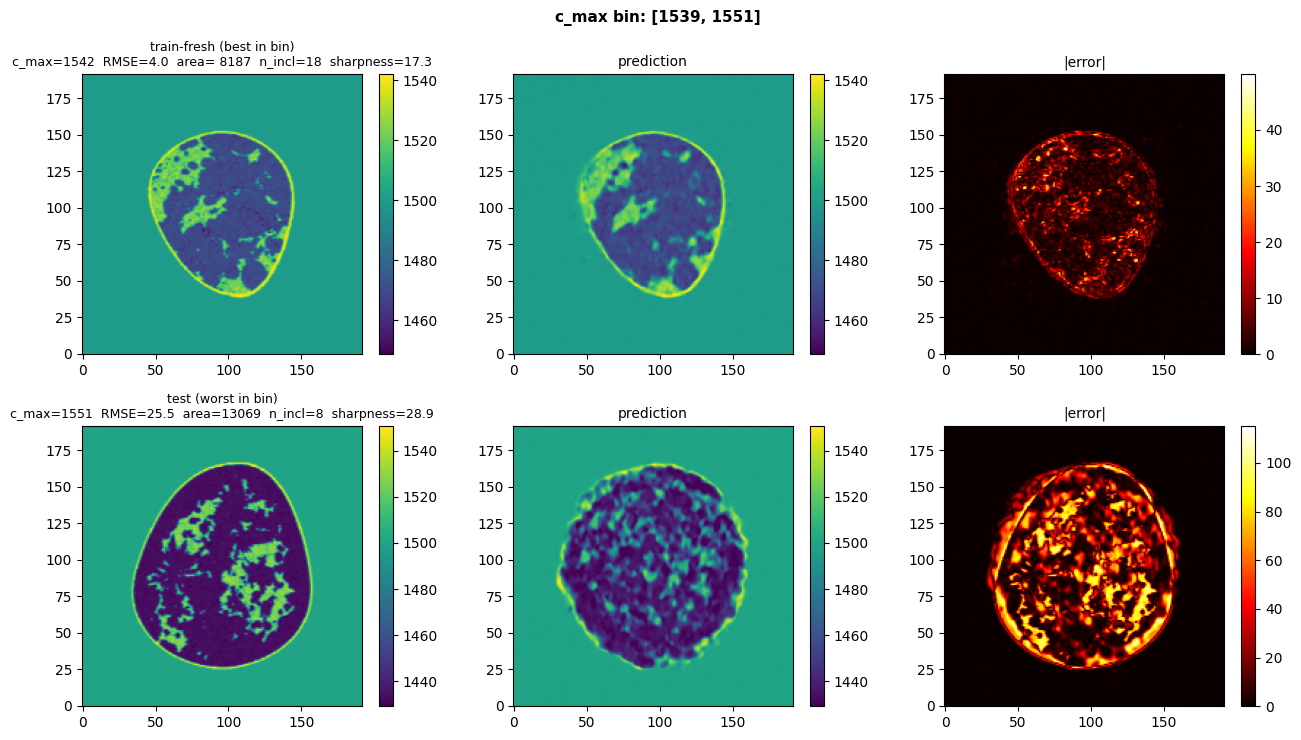

saved /workspace/reference_points/distribution_shift_diagnostic/pair_cmax_1539_1551.png


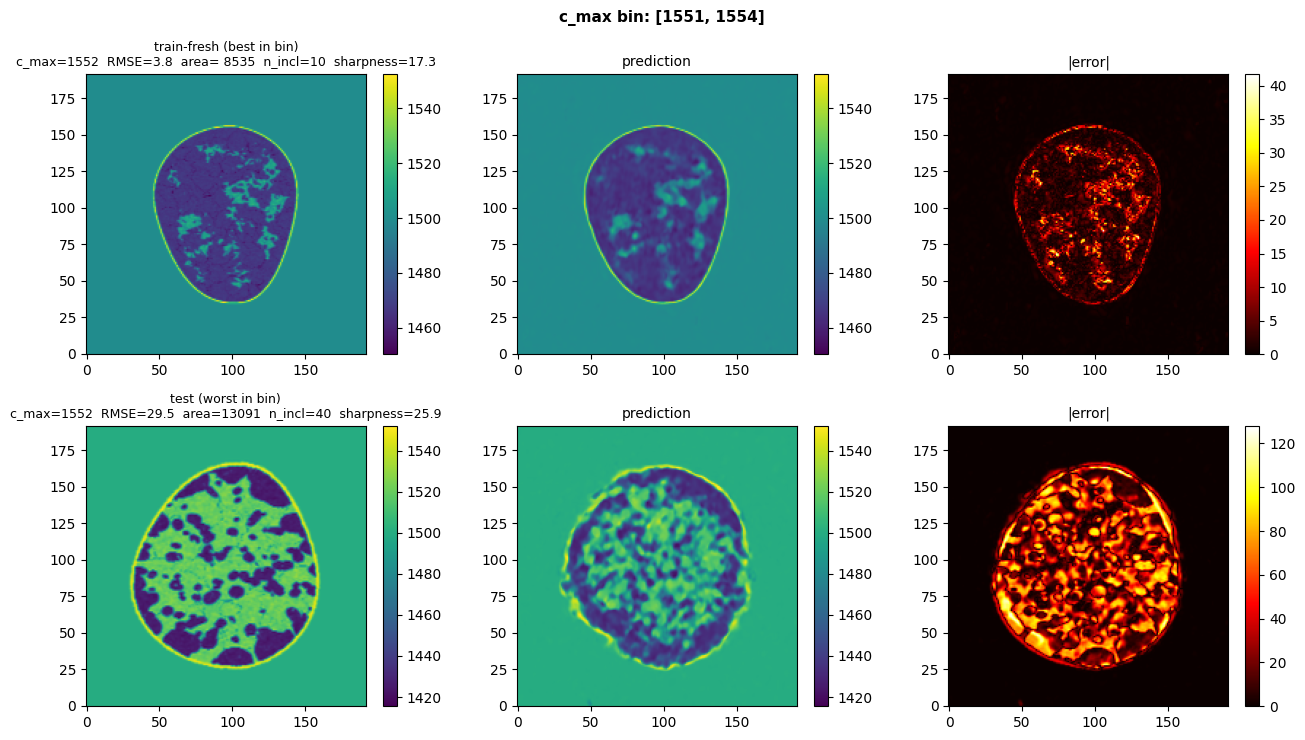

saved /workspace/reference_points/distribution_shift_diagnostic/pair_cmax_1551_1554.png


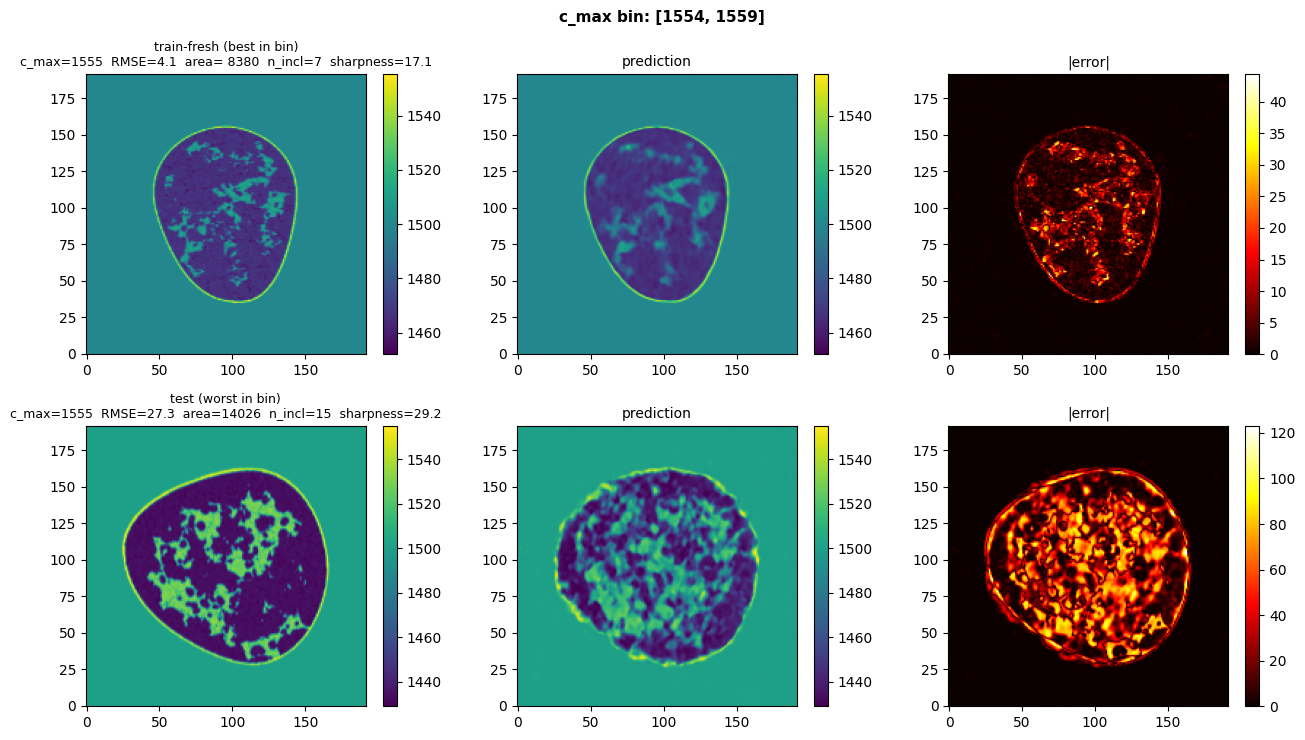

saved /workspace/reference_points/distribution_shift_diagnostic/pair_cmax_1554_1559.png


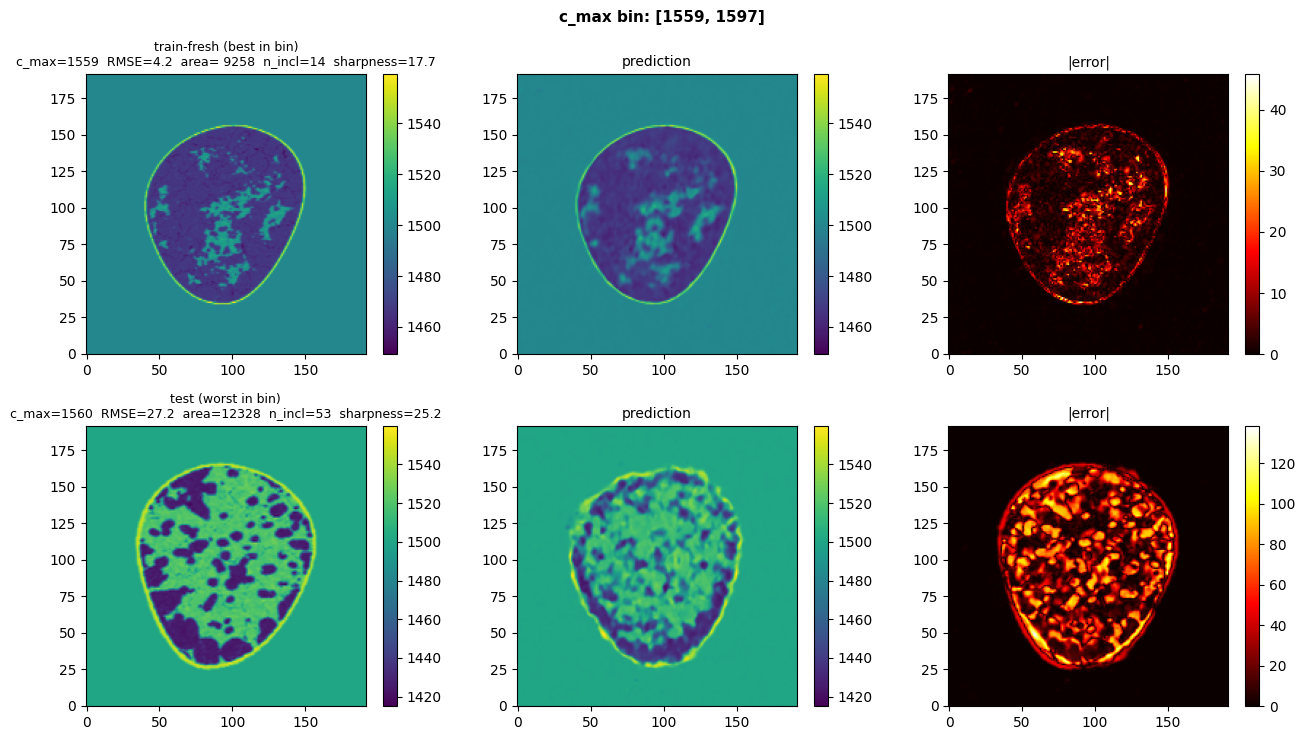

saved /workspace/reference_points/distribution_shift_diagnostic/pair_cmax_1559_1597.png


In [12]:
# Show each pair: 2 rows × 3 cols
for low, high, bf, wt in pairs:
    fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))

    for row, (label, feat) in enumerate([("train-fresh (best in bin)", bf),
                                          ("test (worst in bin)", wt)]):
        path = feat["path"]
        x_tensor, c_target = load_sample(path)
        c_pred = predict(x_tensor)
        err = c_pred - c_target

        im0 = axes[row, 0].imshow(c_target, origin="lower")
        title = (f"{label}\n"
                 f"c_max={feat['c_max']:.0f}  RMSE={feat['rmse']:.1f}  "
                 f"area={feat['phantom_area']:>5d}  "
                 f"n_incl={feat['n_inclusions']}  "
                 f"sharpness={feat['edge_sharpness']:.1f}")
        axes[row, 0].set_title(title, fontsize=9)
        plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)

        im1 = axes[row, 1].imshow(c_pred, origin="lower",
                                   vmin=c_target.min(), vmax=c_target.max())
        axes[row, 1].set_title("prediction", fontsize=10)
        plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)

        im2 = axes[row, 2].imshow(np.abs(err), origin="lower", cmap="hot",
                                   vmin=0, vmax=max(np.abs(err).max(), 1e-3))
        axes[row, 2].set_title("|error|", fontsize=10)
        plt.colorbar(im2, ax=axes[row, 2], fraction=0.046)

    fig.suptitle(f"c_max bin: [{low:.0f}, {high:.0f}]", fontsize=11, fontweight="bold")
    plt.tight_layout()
    fig_path = RUN_DIR / f"pair_cmax_{low:.0f}_{high:.0f}.png"
    plt.savefig(fig_path, dpi=110, bbox_inches="tight")
    plt.show()
    print(f"saved {fig_path}")

## 9. Сводный вывод

Какие признаки одновременно (a) **статистически отличаются** между train-fresh
и test, (b) **коррелируют с RMSE** хотя бы в одном из сплитов? Это и есть
кандидаты на причину distribution shift.

In [13]:
print("\n=== Suspect features (significant distribution diff AND correlation with RMSE) ===\n")
print(f"  {'feature':<24}{'p-value':>14}{'fresh→RMSE':>14}{'test→RMSE':>14}{'verdict':>20}")
print("  " + "-" * 88)

from scipy.stats import spearmanr
suspects = []
for name in feature_names:
    fresh_vals = np.array([f[name] for f in features_fresh])
    test_vals = np.array([f[name] for f in features_test])
    fresh_rmse = np.array([f["rmse"] for f in features_fresh])
    test_rmse = np.array([f["rmse"] for f in features_test])

    pval = stat_results[name]["p_value"]
    if fresh_vals.std() > 1e-6:
        c_fresh, _ = spearmanr(fresh_vals, fresh_rmse)
    else: c_fresh = 0.0
    if test_vals.std() > 1e-6:
        c_test, _ = spearmanr(test_vals, test_rmse)
    else: c_test = 0.0

    # Suspect = significantly different distribution AND meaningful correlation
    is_distrib_shifted = pval < 0.01
    has_rmse_corr = max(abs(c_fresh), abs(c_test)) > 0.2

    if is_distrib_shifted and has_rmse_corr:
        verdict = "PRIME SUSPECT"
        suspects.append(name)
    elif is_distrib_shifted:
        verdict = "shifted but no RMSE link"
    elif has_rmse_corr:
        verdict = "matters but not shifted"
    else:
        verdict = "-"

    print(f"  {name:<24}{pval:>14.2e}{c_fresh:>14.3f}{c_test:>14.3f}{verdict:>20}")

print(f"\nSuspects: {suspects}")
if suspects:
    print("\nThese features differ significantly between train-fresh and test")
    print("AND they correlate with RMSE. They are the most likely causes of the")
    print("distribution shift gap (~6-7 m/s) we observed.")
else:
    print("\nNo single feature explains the gap. The shift may be in joint")
    print("distributions or in features not yet measured (e.g., texture statistics).")


=== Suspect features (significant distribution diff AND correlation with RMSE) ===

  feature                        p-value    fresh→RMSE     test→RMSE             verdict
  ----------------------------------------------------------------------------------------
  phantom_area                  8.97e-01         0.138         0.147                   -
  centroid_offset               3.27e-01         0.130         0.159                   -
  mean_radius                   8.97e-01         0.138         0.147                   -
  n_inclusions                  8.17e-01         0.483         0.556matters but not shifted
  mean_inclusion_size           9.02e-01        -0.461        -0.528matters but not shifted
  inclusion_density             7.23e-01        -0.579        -0.630matters but not shifted
  edge_sharpness                7.09e-01         0.375         0.378matters but not shifted
  c_max                         6.82e-01         0.126         0.180                   -
  c_min    

## 10. Save artifacts

In [14]:
# Save full feature dataframe
import csv
with open(RUN_DIR / "per_sample_features.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(all_features[0].keys()))
    writer.writeheader()
    writer.writerows(all_features)

# Save suspect summary
with open(RUN_DIR / "shift_analysis.json", "w") as f:
    json.dump({
        "suspects": suspects,
        "feature_stats": stat_results,
        "n_train_fresh": len(features_fresh),
        "n_test": len(features_test),
    }, f, ensure_ascii=False, indent=2)

print(f"saved feature CSV and shift_analysis.json to {RUN_DIR}")

saved feature CSV and shift_analysis.json to /workspace/reference_points/distribution_shift_diagnostic
